**StepI: Import Libraries**

In [ ]:
# ================================================================
# SETUP — import all libraries we need for the entire session
# ================================================================
import pandas as pd                    # data loading & manipulation (tables)
import numpy as np                     # numerical operations
import matplotlib.pyplot as plt        # basic plotting
import seaborn as sns                  # prettier statistical plots, built on matplotlib
from sklearn.model_selection import train_test_split   # Step 6: split data
from sklearn.tree import DecisionTreeClassifier         # Step 5: our model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Step 7

In [ ]:
# Make our charts look clean and consistent for the whole notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
print("Libraries loaded. Ready to build the pipeline.")

Libraries loaded. Ready to build the pipeline.


**# Problem statement**

In [ ]:
# STEP 1: Problem Definition
# ----------------------------------------------------------------
# T (Task)        -> Predict Survived (1) or Not Survived (0)
# E (Experience)  -> Historical passenger records with KNOWN outcomes
# P (Performance) -> Accuracy: % of passengers we correctly classify
TASK = "Classify: did this passenger survive? (1 = yes, 0 = no)"
print("Problem definition:", TASK)

Problem definition: Classify: did this passenger survive? (1 = yes, 0 = no)


In [ ]:
# STEP 2: Data Collection — loading the dataset# ----------------------------------------------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape of dataset (rows, columns):", df.shape)
df.head()   # preview the first 5 rows
# Quick structural check — column names, data types, missing values
df.info()
# How many missing values does each column have?
df.isnull().sum().sort_values(ascending=False)

Shape of dataset (rows, columns): (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
df.head()   # preview the first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


/tmp/ipykernel_580/3950508989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Survived", palette=["#e74c3c", "#2ecc71"])


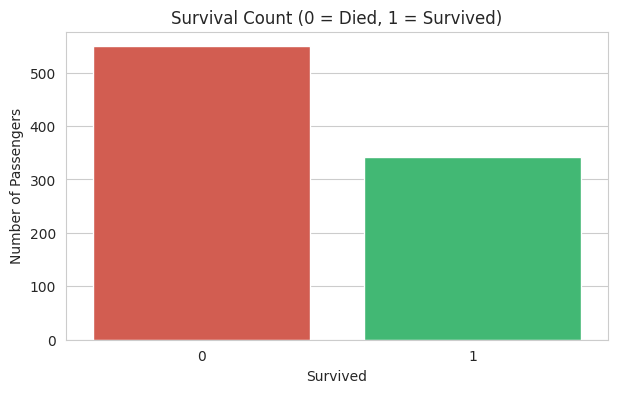

In [ ]:
# EDA 1: Overall survival counts
plt.figure()
sns.countplot(data=df, x="Survived", palette=["#e74c3c", "#2ecc71"])
plt.title("Survival Count (0 = Died, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

/tmp/ipykernel_580/3084021668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Pclass", y="Survived", palette="Blues_d")


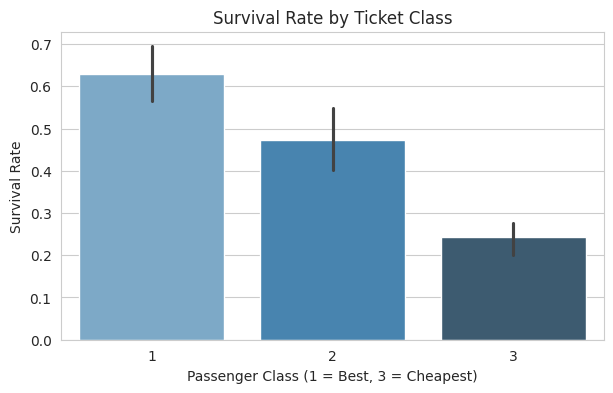

In [ ]:
# EDA 2: Survival rate by passenger class
plt.figure()
sns.barplot(data=df, x="Pclass", y="Survived", palette="Blues_d")
plt.title("Survival Rate by Ticket Class")
plt.xlabel("Passenger Class (1 = Best, 3 = Cheapest)")
plt.ylabel("Survival Rate")
plt.show()


/tmp/ipykernel_580/3825753333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Sex", y="Survived", palette="Set2")


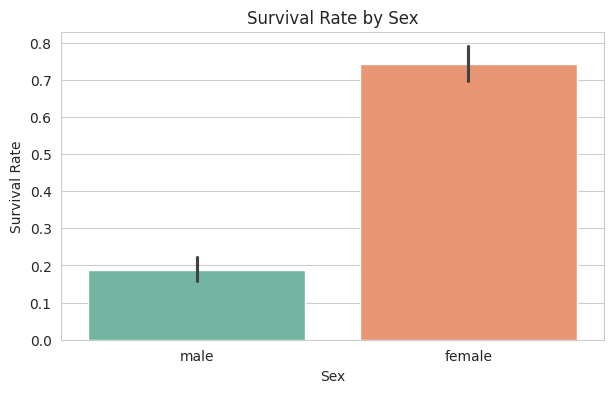

In [ ]:
# EDA 3: Survival rate by sex
plt.figure()
sns.barplot(data=df, x="Sex", y="Survived", palette="Set2")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()


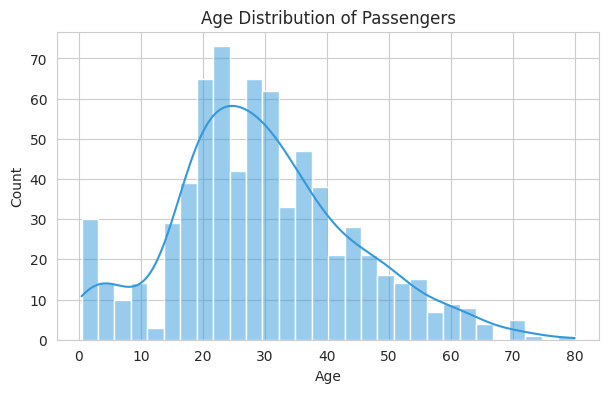

In [ ]:
# EDA 4: Age distribution (all passengers)
plt.figure()
sns.histplot(df["Age"].dropna(), bins=30, kde=True, color="#3498db")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

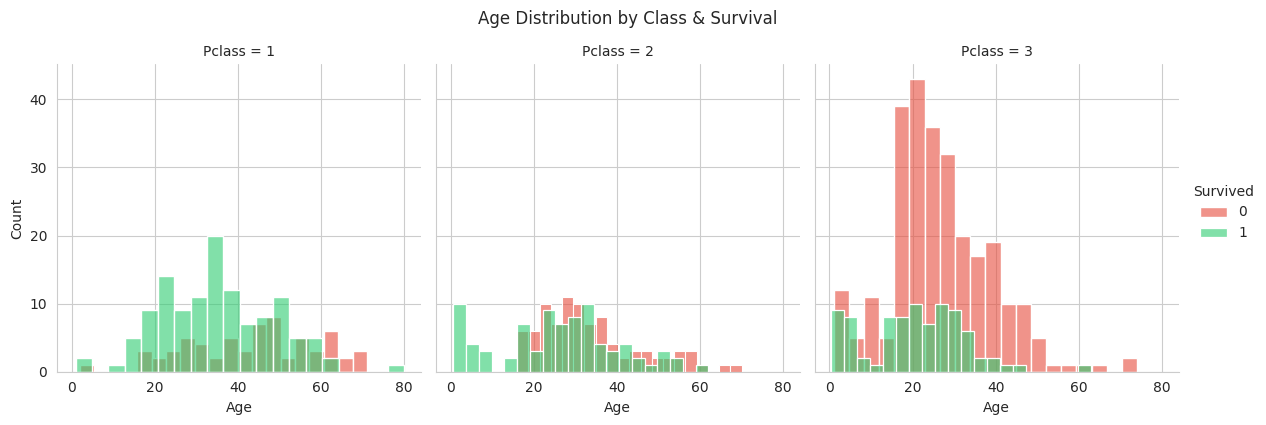

In [ ]:
# EDA 5: Age distribution split by survival outcome, across ticket class
g = sns.FacetGrid(df, col="Pclass", hue="Survived", height=4, palette=["#e74c3c", "#2ecc71"])
g.map(sns.histplot, "Age", bins=20, alpha=0.6)
g.add_legend(title="Survived")
g.fig.suptitle("Age Distribution by Class & Survival", y=1.05)
plt.show()
